# Scikit-Learn

## Exploratory analysis

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from matplotlib.colors import ListedColormap
from sklearn import (
    datasets,
    decomposition,
    linear_model,
    metrics,
    model_selection,
    naive_bayes,
    pipeline,
)

In [2]:
%config InlineBackend.figure_format="retina"  # For high DPI display

print(sklearn.__version__)  # Version tested on sklearn.__version__ == 1.6.x

1.7.0


---

### Classification (digits)

Let's look at the classification model performance in terms of precision and recall.

#### Data loading

https://scikit-learn.org/stable/datasets/toy_dataset.html#digits-dataset

In [3]:
digits = datasets.load_digits()

In [4]:
# Flatten the images
n_samples = len(digits.images)
print(digits.images.shape)

data = digits.images.reshape([n_samples, -1])

print(data.shape, digits.target.shape)

(1797, 8, 8)
(1797, 64) (1797,)


Randomly select the training and test dataset.

<span style="color:red">Implement your solution below</span>

In [5]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(data, digits.target, test_size=0.5, shuffle=False)

#### Train the models

Train the model using, e.g., the [Gaussian Naive Bayes Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html).

<span style="color:red">Implement your solution below</span>

In [6]:
model = naive_bayes.GaussianNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

#### Evaluate

Evaluate with the [`accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html).

Then give a more complete result, including precision, recall and f1-score with the method [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html).

<span style="color:red">Implement your solution below</span>

In [7]:
print(metrics.accuracy_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

0.8075639599555061
              precision    recall  f1-score   support

           0       0.98      0.95      0.97        88
           1       0.81      0.74      0.77        91
           2       0.87      0.84      0.85        86
           3       0.88      0.79      0.83        91
           4       1.00      0.73      0.84        92
           5       0.70      0.81      0.76        91
           6       0.96      0.99      0.97        91
           7       0.65      0.81      0.72        89
           8       0.61      0.76      0.68        88
           9       0.77      0.66      0.71        92

    accuracy                           0.81       899
   macro avg       0.82      0.81      0.81       899
weighted avg       0.82      0.81      0.81       899



#### Confusion matrix

Use the class [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
to display the confusion matrix.

Briefly comment on the results.

Note that the `.confusion_matrix` attribute of the created object allows to obtain the confusion matrix in the form of an array.

<span style="color:red">Implement your solution below</span>

[[84  0  0  0  0  2  0  0  1  1]
 [ 0 67  2  0  0  0  0  2 13  7]
 [ 0  8 72  0  0  1  2  0  3  0]
 [ 0  2  2 72  0  2  0  2  9  2]
 [ 1  0  0  0 67  0  0 22  1  1]
 [ 0  2  0  4  0 74  1  3  2  5]
 [ 0  1  0  0  0  0 90  0  0  0]
 [ 0  0  2  0  0 12  0 72  2  1]
 [ 0  2  5  0  0  9  0  4 67  1]
 [ 1  1  0  6  0  5  1  6 11 61]]


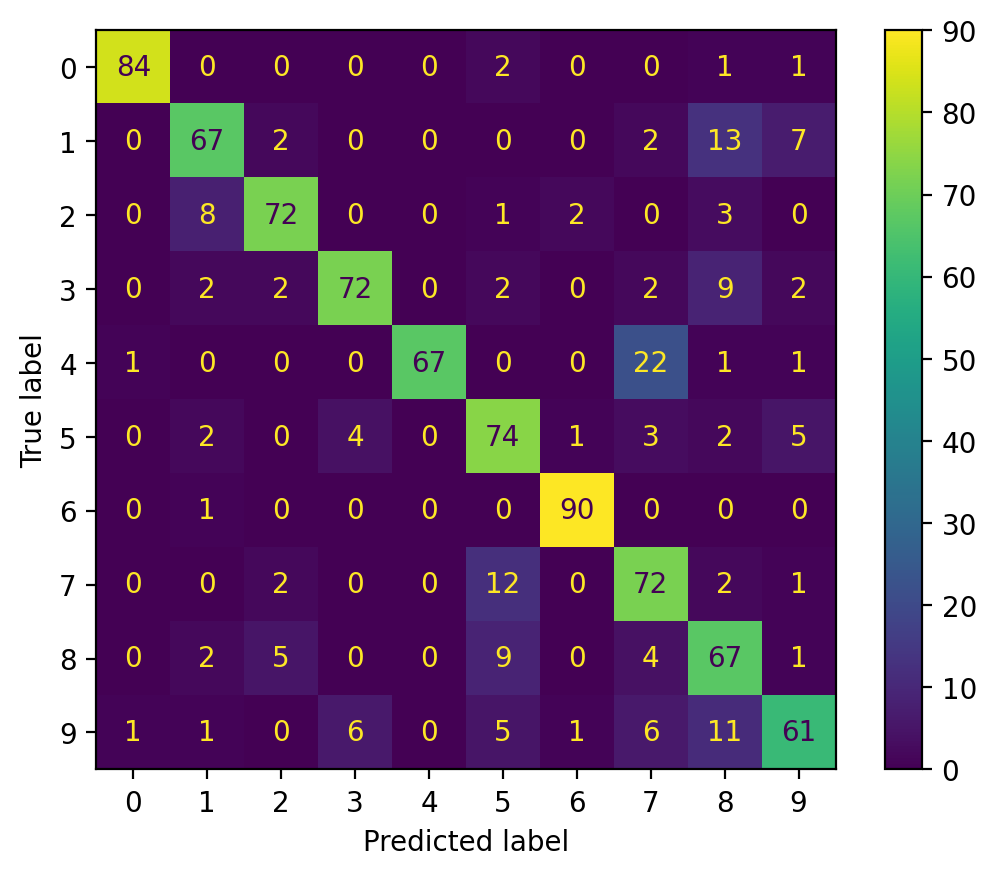

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
CM = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print(CM.confusion_matrix)
plt.show()

We see that most digits are well classified, with some confusion between 4 and 7, between 7 and 5 and between 1 and 8.

#### Error visualization

Identify the most confusing cases.

Identify misclassified instances for the lowest f1-scoring cipher class and visualize them with the code below.

You may use the function [numpy.where](https://numpy.org/doc/stable/reference/generated/numpy.where.html) to find the index of the concerned instances.

In [10]:
def plot_digit(idx, xs, ys=None, pred_ys=None):
    if ys is not None:
        print(f"Digit value:\t{ys[idx]}")
    if pred_ys is not None:
        print(f"Prediction:\t{pred_ys[idx]}")

    plt.figure(figsize=(3, 3))
    plt.imshow(
        xs[idx].reshape(8, -1),
        cmap=plt.cm.gray_r,
        interpolation="nearest",
    )

<span style="color:red">Implement your solution below</span>

Lowest F1 score digit: 8
Digit value:	8
Prediction:	5
Digit value:	8
Prediction:	1
Digit value:	9
Prediction:	3
Digit value:	1
Prediction:	2
Digit value:	5
Prediction:	3
Digit value:	5
Prediction:	9
Digit value:	5
Prediction:	3
Digit value:	9
Prediction:	3
Digit value:	4
Prediction:	7
Digit value:	5
Prediction:	3
Digit value:	3
Prediction:	9


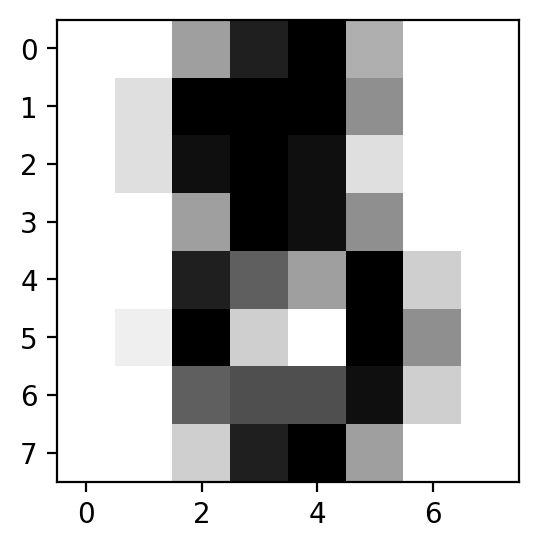

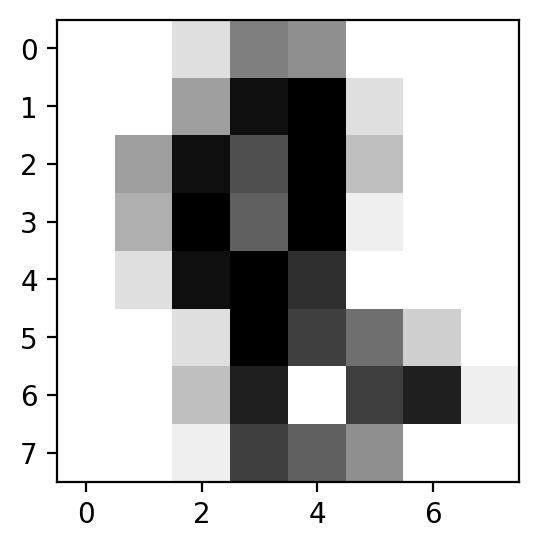

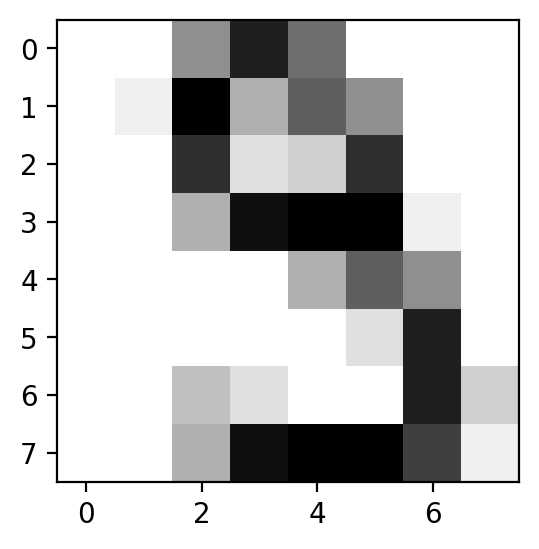

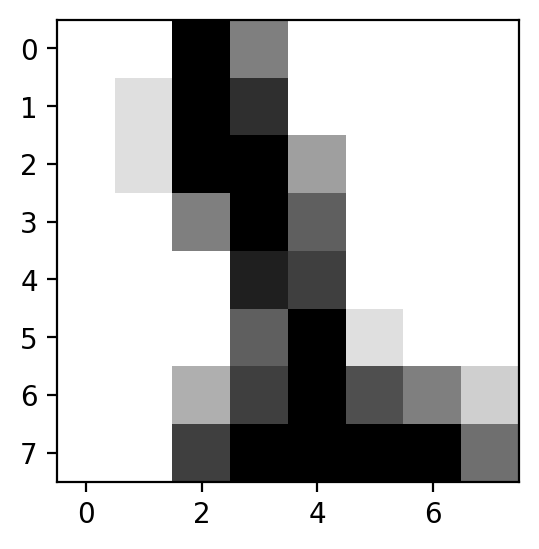

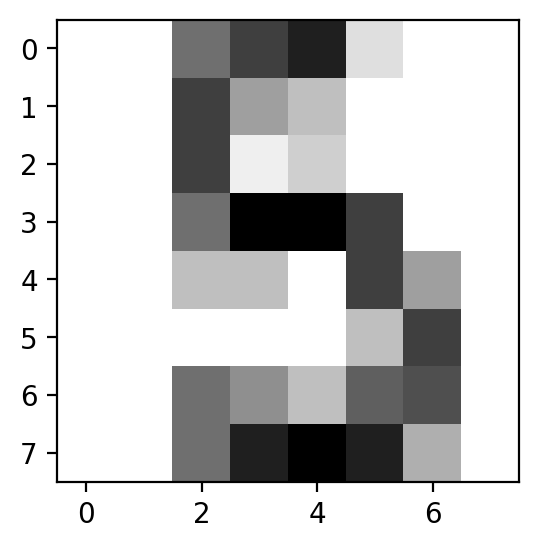

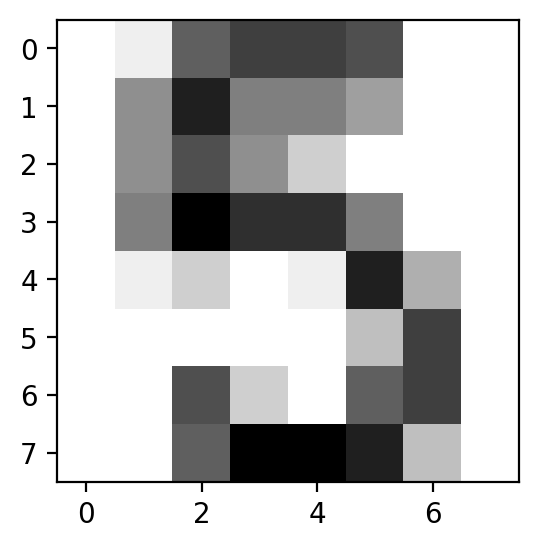

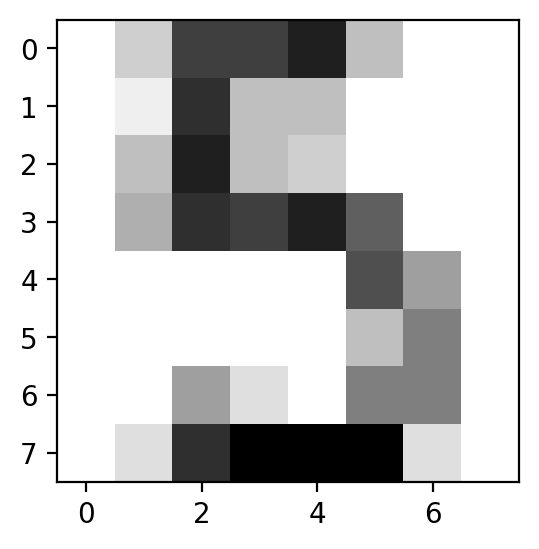

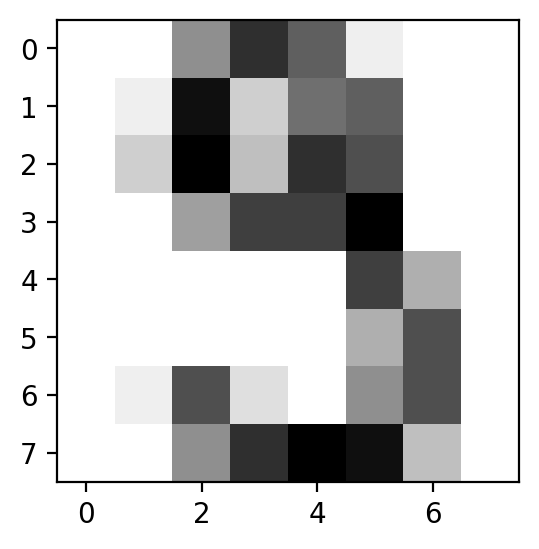

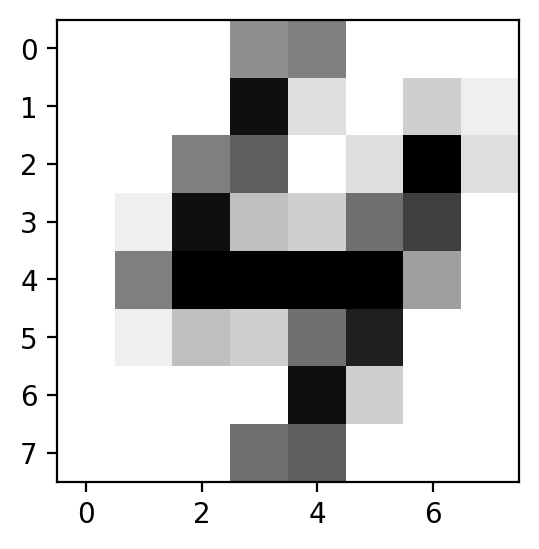

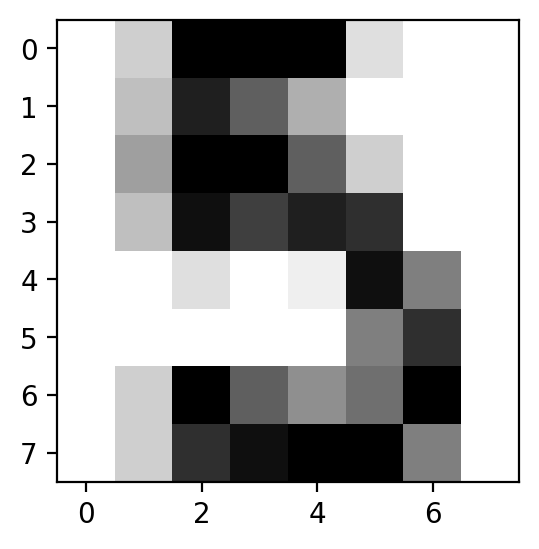

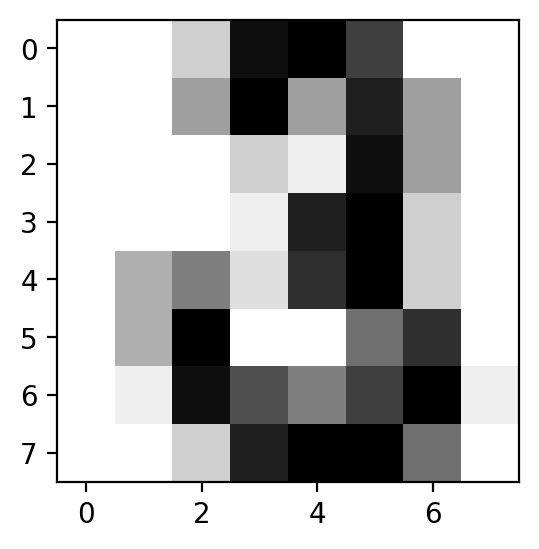

In [12]:
lowest_f1_scoring = np.argmin(metrics.precision_recall_fscore_support(y_test, y_pred)[2])
print(f"Lowest F1 score digit: {lowest_f1_scoring}")
for i, y in enumerate(np.where(y_test == lowest_f1_scoring)[0]):
    if y_pred[i] != y_test[i]:
        plot_digit(i, x_test, y_test, y_pred)
      

---

### PCA

Try to reduce the number of features through the ([PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)), by choosing, e.g., the 10 first principal components.

#### PCA and training/evaluation data selection

<span style="color:red">Implement your solution below</span>

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
data_pca = pca.fit_transform(data)
print(data_pca.shape)

x_pca_train, x_pca_test, y_pca_train, y_pca_test = model_selection.train_test_split(data_pca, digits.target, test_size=0.5, shuffle=False)

(1797, 10)


#### Model training

<span style="color:red">Implement your solution below</span>

In [15]:
model.fit(x_pca_train, y_pca_train)
y_pred_pca = model.predict(x_pca_test)

#### Evaluation

<span style="color:red">Implement your solution below</span>

0.8787541713014461
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        88
           1       0.89      0.81      0.85        91
           2       0.87      0.97      0.92        86
           3       0.87      0.82      0.85        91
           4       0.98      0.96      0.97        92
           5       0.76      0.84      0.80        91
           6       0.98      0.98      0.98        91
           7       0.91      0.97      0.93        89
           8       0.85      0.64      0.73        88
           9       0.74      0.91      0.82        92

    accuracy                           0.88       899
   macro avg       0.88      0.88      0.88       899
weighted avg       0.88      0.88      0.88       899



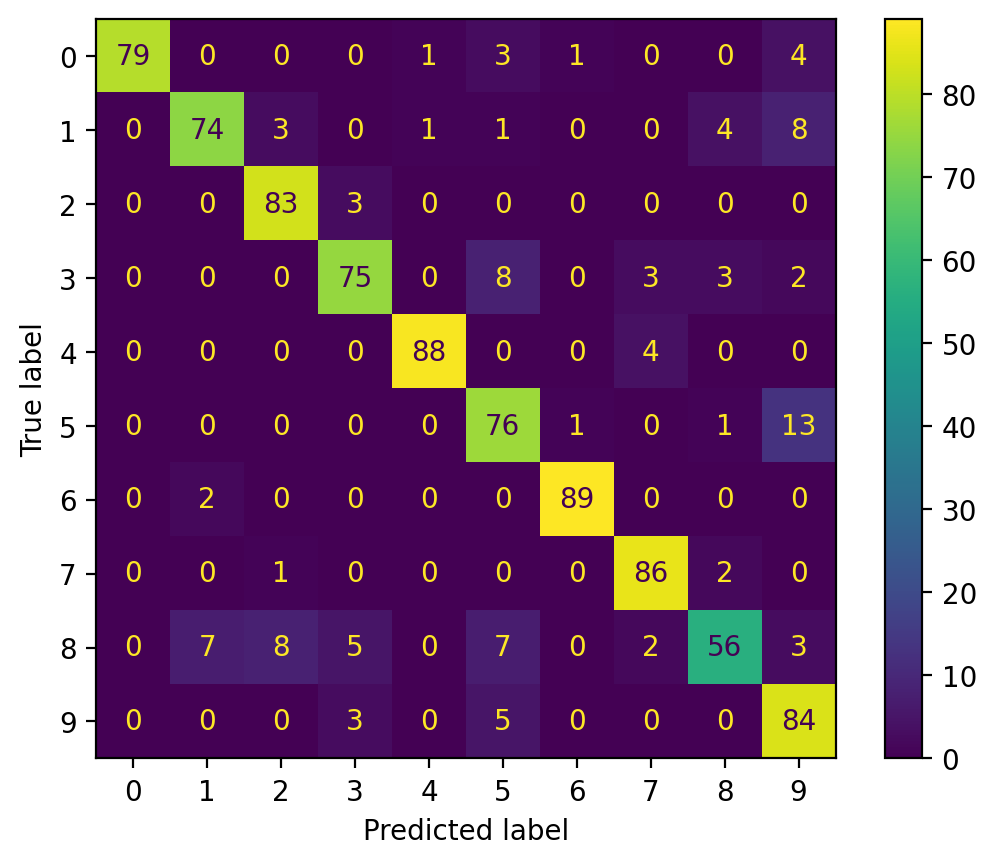

In [17]:
print(metrics.accuracy_score(y_pca_test, y_pred_pca))
print(metrics.classification_report(y_pca_test, y_pred_pca))
from sklearn.metrics import ConfusionMatrixDisplay
CM = ConfusionMatrixDisplay.from_predictions(y_pca_test, y_pred_pca)
plt.show()

---

### Cross-Validation

#### Data preparation

Use the function [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to implement cross-validation.

You may choose to do 10 splits (`cv=10`).

Choose as *scoring* `"f1_weighted"`, then the function will return the corresponding scores in an array.

By way of example and in order to be able to compare the results with the previous ones, the first application will be done on the entire dataset (which is usually not recommended).

<span style="color:red">Implement your solution below</span>

In [18]:
SCORINGS = "f1_weighted"

from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, data, digits.target, cv=5, scoring=SCORINGS)
print(f"Cross-validation {SCORINGS} scores: {scores}")

Cross-validation f1_weighted scores: [0.77067569 0.78308708 0.79780653 0.87194974 0.80586668]


Show the results with a [`plt.bar`] (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) which includes an error bar `yerr` equal to 1 [standard deviation](https://numpy.org/doc/stable/reference/generated/numpy.std.html), as well as in a [`boxplot`](https://matplotlib.org/stable/api/_as_gen/ matplotlib.pyplot.boxplot.html).

<span style="color:red">Implement your solution below</span>

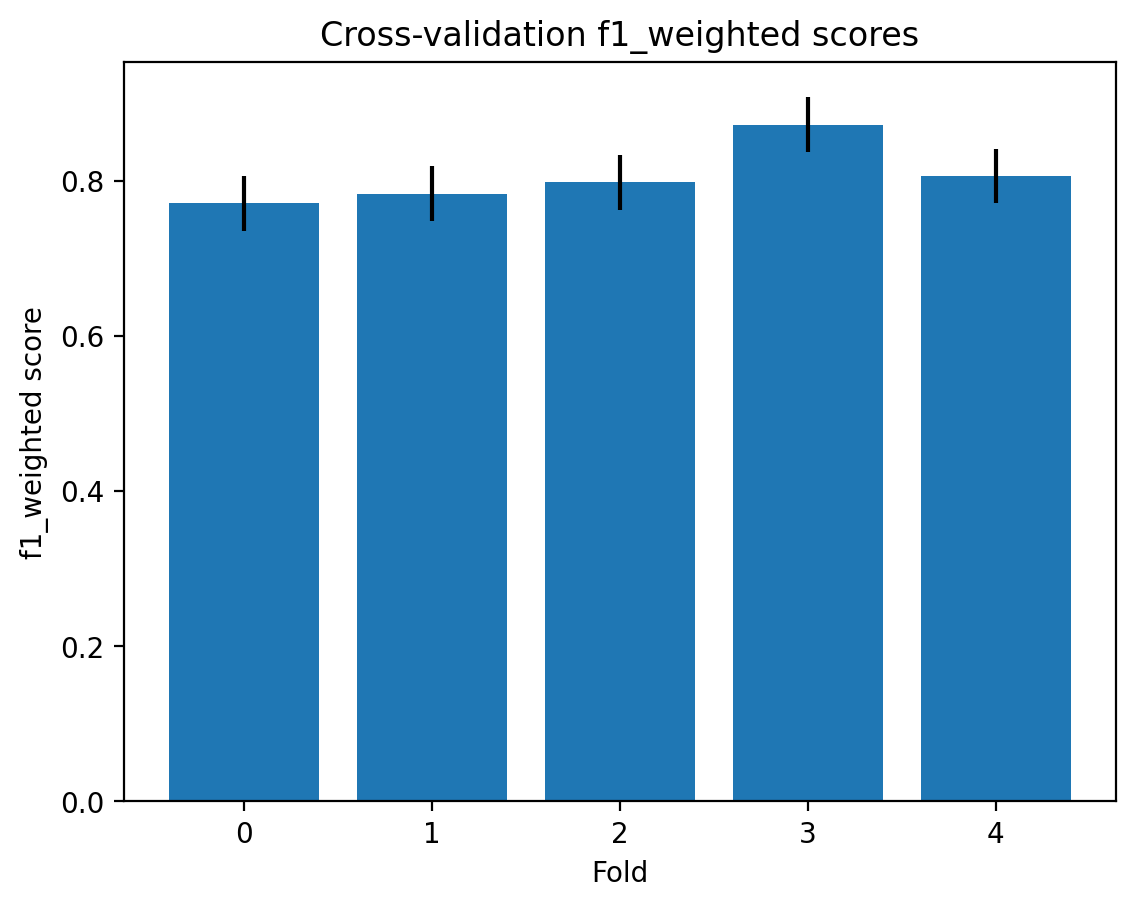

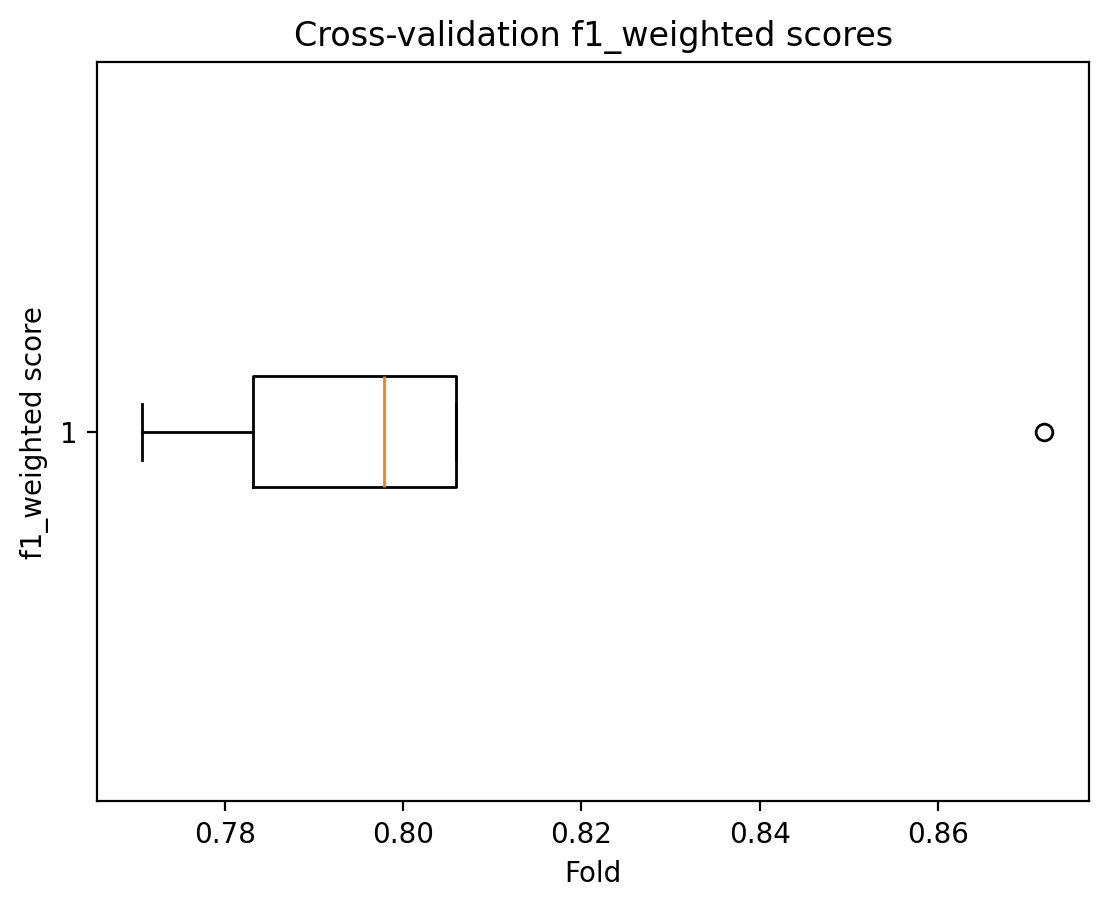

In [22]:
plt.bar(range(len(scores)), scores, yerr=np.std(scores))
plt.title(f"Cross-validation {SCORINGS} scores")
plt.xlabel("Fold")
plt.ylabel(f"{SCORINGS} score")
plt.show()
plt.title(f"Cross-validation {SCORINGS} scores")
plt.xlabel("Fold")
plt.ylabel(f"{SCORINGS} score")
plt.boxplot(scores, vert=False)
plt.show()

---

### Grid Search

This time, we are going to use cross-validation for one of its primary use: to validate the choice of hyperparameters.

We will use the class
[`model_selection.GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) to choose the best number of main components for the PCA.

This class makes it possible to test several hyperparameters (stored in a dictionary) and to test them via cross-validation (hence the CV in the name).

To do this, we no longer need to worry about creating the different subsets, the `GridSearchCV` class does it for us.

In [23]:
param_grid = {"pca__n_components": [1, 2, 5, 10, 20, 30, 40, 60]}

We're going to use a [`pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) to do PCA compression and training with the model together, which will allow us to modify the hyperparameters at any step of the process through a single command.

We will have to use the exact names of the hyperparameters to modify in the dictionary, preceded by the name of the module and a double *underscore* (e.g., here: `"pca__"`), in order to be able to assign them to the right step of the `pipeline`.

<span style="color:red">Implement your solution below</span>

In [24]:
# Define the pipeline
from sklearn.pipeline import Pipeline

pipe = Pipeline(
    [
        ("pca", decomposition.PCA()),
        ("gnb", naive_bayes.GaussianNB()),
    ]
)

In [25]:
# Define the gridsearch using the pipeline and fit the model
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring=SCORINGS)
grid_search.fit(x_train, y_train)

,estimator,Pipeline(step...aussianNB())])
,param_grid,"{'pca__n_components': [1, 2, ...]}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,30


In [26]:
# Print the best prediction score obtained
# and its corresponding hyperparameter value
grid_search.best_score_, grid_search.best_params_

(np.float64(0.8849375876979639), {'pca__n_components': 30})

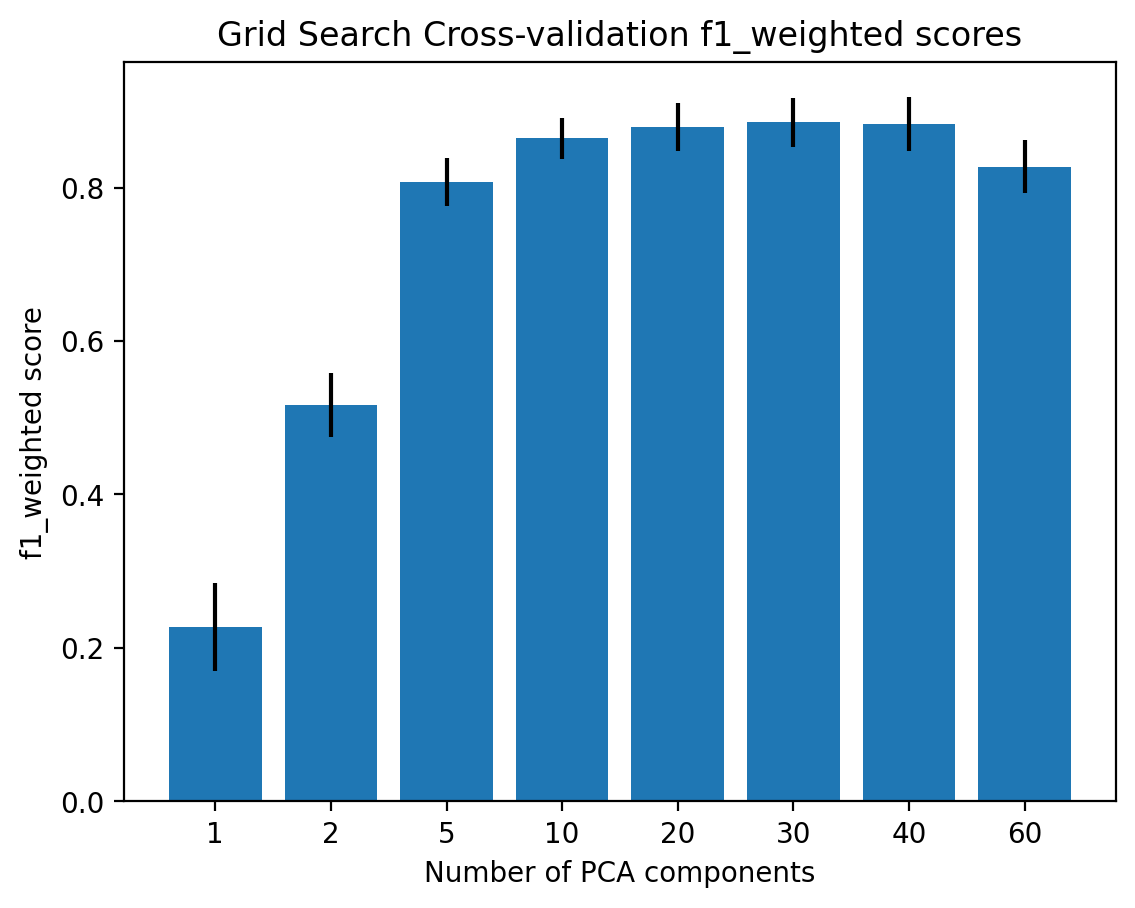

In [27]:
# Plot a bar plot (or boxplot) showing the different prediction scores
# for each tested hyperparameter
# (including the error bars if bar plots are chosen)
plt.bar(
    [str(params["pca__n_components"]) for params in grid_search.cv_results_["params"]],
    grid_search.cv_results_["mean_test_score"],
    yerr=grid_search.cv_results_["std_test_score"],
)
plt.title(f"Grid Search Cross-validation {SCORINGS} scores")
plt.xlabel("Number of PCA components")
plt.ylabel(f"{SCORINGS} score")
plt.show()

## Further exercises

Using the `.predict_proba` method of` linear_model.LogisticRegression`, use the result of the prediction to select a particular threshold (*threshold*) to influence the classification performances.

*   Can you get 100% [accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)?
*   Can you get 100% of [recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)?
*   Measure the values of [f1-scores](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) and comment.
*   Plot the [ROC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html) from multiple threshold values.
*   Compare the [AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html) (area under the ROC curve) of the `linear_model.LogisticRegression` and of `naive_bayes. GaussianNB()`.

<span style="color:red">Implement your solution below and comment briefly</span>

Metrics for threshold = 0.5:
Accuracy: 0.9800
Recall: 0.8242
F1 Score: 0.8929


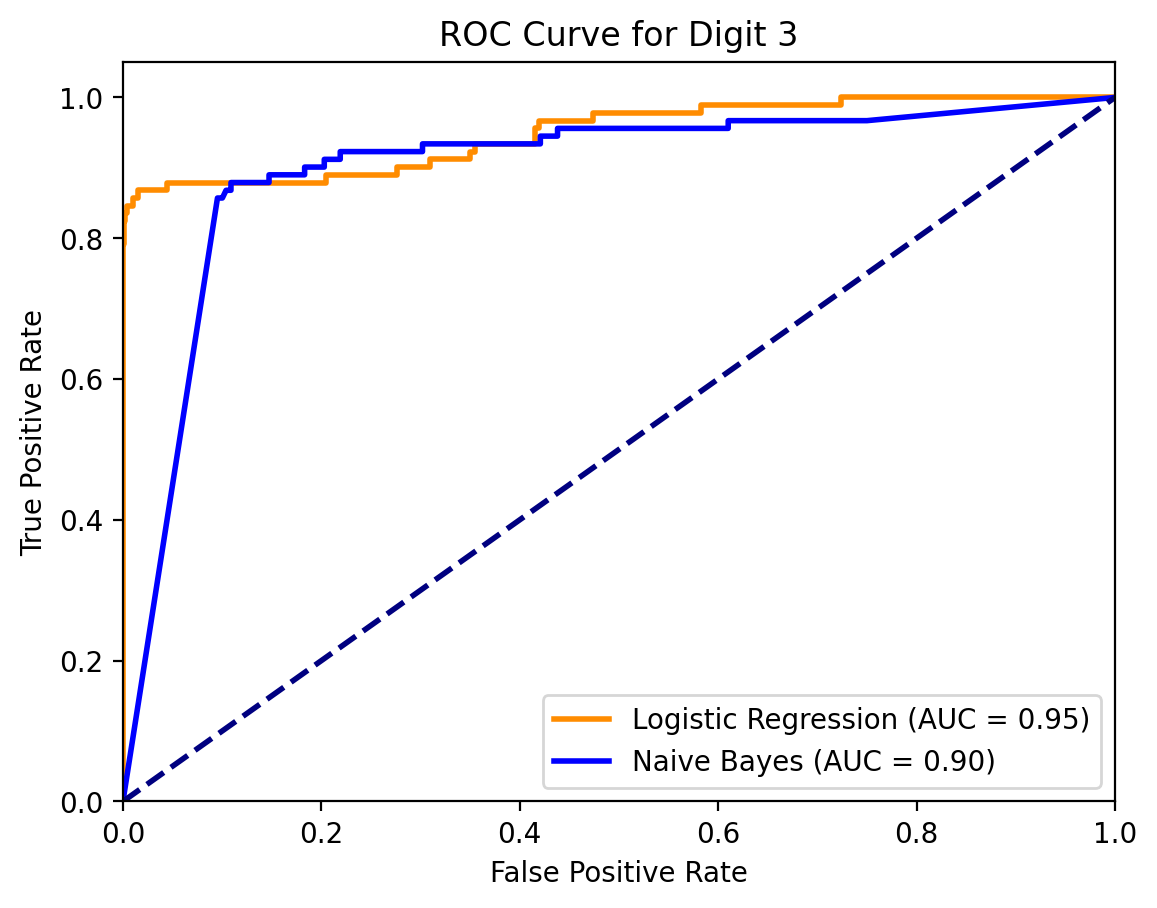


--- Comments ---
Can achieve 100% Recall with threshold <= 0.0000

Highest F1 score potential can be found by iterating thresholds.


In [29]:
# Select a specific digit (e.g., the digit 3) to convert the problem into a binary classification
digit_class = 3
y_train_binary = (y_train == digit_class).astype(int)
y_test_binary = (y_test == digit_class).astype(int)

# Logistic Regression
lr_model = linear_model.LogisticRegression(max_iter=1000)
lr_model.fit(x_train, y_train_binary)

# Get probabilities for the positive class
y_scores_lr = lr_model.predict_proba(x_test)[:, 1]

# Predict with a specific threshold (e.g., 0.5 is default)
threshold = 0.5
y_pred_lr_thresh = (y_scores_lr >= threshold).astype(int)

# Evaluation metrics
print(f"Metrics for threshold = {threshold}:")
print(f"Accuracy: {metrics.accuracy_score(y_test_binary, y_pred_lr_thresh):.4f}")
print(f"Recall: {metrics.recall_score(y_test_binary, y_pred_lr_thresh):.4f}")
print(f"F1 Score: {metrics.f1_score(y_test_binary, y_pred_lr_thresh):.4f}")

# ROC Curve for Logistic Regression
fpr_lr, tpr_lr, thresholds_lr = metrics.roc_curve(y_test_binary, y_scores_lr)
roc_auc_lr = metrics.auc(fpr_lr, tpr_lr)

# Naive Bayes for comparison
nb_model = naive_bayes.GaussianNB()
nb_model.fit(x_train, y_train_binary)
y_scores_nb = nb_model.predict_proba(x_test)[:, 1]
fpr_nb, tpr_nb, _ = metrics.roc_curve(y_test_binary, y_scores_nb)
roc_auc_nb = metrics.auc(fpr_nb, tpr_nb)

# Plot ROC Curves
plt.figure()
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_nb, tpr_nb, color='blue', lw=2, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for Digit {digit_class}')
plt.legend(loc="lower right")
plt.show()

# Comments on finding 100% metrics
print("\n--- Comments ---")
# Check for 100% recall
indices_recall_100 = np.where(tpr_lr == 1.0)[0]
if len(indices_recall_100) > 0:
  print(f"Can achieve 100% Recall with threshold <= {thresholds_lr[indices_recall_100[-1]]:.4f}")
else:
  print("Cannot achieve 100% Recall strictly.")

# Check for perfect accuracy (not direct from ROC, but ideally top left corner)
print(f"\nHighest F1 score potential can be found by iterating thresholds.")

---